# Notebook for computing linear trends and residuals

This notebook loads exported STCD data and analyses long-term behaviour.

- **Load data** produced by the companion notebook (e.g. `gop25wd03_stcd_licb_detr.csv`) from the `exports/` directory.
- **Specify input** by setting:
  - `PRODUCT` – type of product (`stcd`)
  - `SOLUTION` – solution identifier (e.g. `gop25wd04`)
  - `STATION` – station name (e.g. `licb`)
- **Parse** the raw table and convert MJD to calendar dates and decimal years.
- **Estimate a linear trend** for the East (`dE`), North (`dN`) and Up (`dU`) components (slope, intercept, R²).
- **Detrend the series** by subtracting the fitted line to obtain residuals.
- **Visualize** raw data, fitted trend and residuals.
- **Export residuals** to CSV (`exports/{solution}_{product}_{station}_detr.csv`) for later spectral or periodicity analysis.

### Imports

**Standard library**
- `pathlib.Path`, `datetime`, `timedelta`

**Third-party**
- `numpy` – numerical arrays (https://numpy.org)
- `pandas` – data frames (https://pandas.pydata.org)
- `matplotlib.pyplot` – plotting (https://matplotlib.org)
- `scipy.stats` – statistics & regression (https://scipy.org)

**doris**
- `doris.analysis.stations.loading.load_station_dataframe` – STCD loader
- `doris.analysis.stations.trend` – piecewise trend fitting
- `doris.output.plots` – plot scale helpers

In [1]:
# --- Standard library ---
import sys
from pathlib import Path
from datetime import datetime, timedelta

# --- Third-party packages ---
try:
    import numpy as np
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from scipy import stats
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# --- doris package ---
_src = Path("../../src").resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# --- doris package ---
try:
    from doris.output.plots import uniform_y_scale_policy, set_unit_ticks
    from doris.analysis.stations.trend import fit_piecewise_trend, fit_linear_trend
    from doris.analysis.stations.loading import load_station_dataframe
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory: notebooks/stations."
    ) from e

### Paths and constants

In [5]:
# --- Dataset selection ---
PRODUCT  = "stcd".strip().lower()
SOLUTION = "gop25wd04".strip().lower()
STATION  = "KIVC".strip().lower()

# --- Output root ---
OUTPUT_ROOT = Path("../../data")

# --- Directory layout ---
DATA_DIR   = OUTPUT_ROOT / PRODUCT / SOLUTION
EXPORT_DIR = DATA_DIR / "exports" / STATION
IMAGES_DIR = Path("../../LaTeX/images/results/stations") / STATION

# Create dirs
for d in [DATA_DIR, EXPORT_DIR, IMAGES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- File names ---
BASE_NAME = f"{SOLUTION}_{PRODUCT}_{STATION}"

DETR_CSV   = EXPORT_DIR / f"{BASE_NAME}_detr.csv"
IMAGE_NAME = BASE_NAME

# --- Plot title ---
title = f"{SOLUTION} – {PRODUCT} – {STATION}"

# --- Components ---
components = ["dE", "dN", "dU"]

# --- Debug ---
print("📁 DATA_DIR:   ", DATA_DIR)
print("📤 EXPORT_DIR: ", EXPORT_DIR)
print("🖼 IMAGES_DIR: ", IMAGES_DIR)

📁 DATA_DIR:    ..\..\data\stcd\gop25wd04
📤 EXPORT_DIR:  ..\..\data\stcd\gop25wd04\exports\kivc
🖼 IMAGES_DIR:  ..\..\LaTeX\images\results\stations\kivc


### Načtení STCD dat

Místo inline helperů (`load_stcd`, `infer_mjd_step`, `fill_missing_mjd`,
`mjd_to_date`, `decimal_year`) používáme `load_station_dataframe` z knihovny
`doris.analysis.stations.loading`.

Funkce provede v jednom volání:
1. Parsování STCD souboru (vyhledání prvního numerického řádku, čtení 13 sloupců).
2. Přidání sloupců `Date` (datetime) a `year` (desetinný rok).
3. Regularizaci MJD mřížky – chybějící epochy jsou doplněny jako NaN řádky.

Výsledkem je DataFrame s columns `MJD, Date, year, dE, dN, dU, sE, sN, sU`.

In [6]:
# --- Načtení celé časové řady bez ořezu ---
STCD_PATH = DATA_DIR / f"{SOLUTION}.{PRODUCT}.{STATION}"

df_all = load_station_dataframe(STCD_PATH, fill_gaps=True)

reg = df_all.attrs.get("regularize", {})
print(
    f"Načteno {len(df_all)} řádků | "
    f"krok: {reg.get('step_days')} dní | "
    f"doplněno mezer: {reg.get('rows_added')}"
)
df_all

Načteno 472 řádků | krok: 7 dní | doplněno mezer: 2


,MJD,Date,year,dE,dN,dU,sE,sN,sU
0,57554.5,2016-06-15 12:00:00,2016.454918,416.9,55.6,40.5,8.8,6.1,6.5
1,57561.5,2016-06-22 12:00:00,2016.474044,448.4,58.1,4.8,5.3,3.6,3.8
2,57568.5,2016-06-29 12:00:00,2016.493169,452.6,75.7,5.9,5.1,3.3,3.5
3,57575.5,2016-07-06 12:00:00,2016.512295,453.1,64.3,1.5,5.1,3.4,3.6
4,57582.5,2016-07-13 12:00:00,2016.531421,464.4,65.7,13.1,4.9,3.4,3.6
...,...,...,...,...,...,...,...,...,...
467,60823.5,2025-05-28 12:00:00,2025.404110,706.0,112.8,5.2,4.0,2.9,3.0
468,60830.5,2025-06-04 12:00:00,2025.423288,711.6,113.2,-1.6,4.3,3.0,3.2
469,60837.5,2025-06-11 12:00:00,2025.442466,692.3,110.7,-1.4,4.5,3.1,3.2
470,60844.5,2025-06-18 12:00:00,2025.461644,710.3,110.1,6.7,4.2,2.9,3.1


### Display data

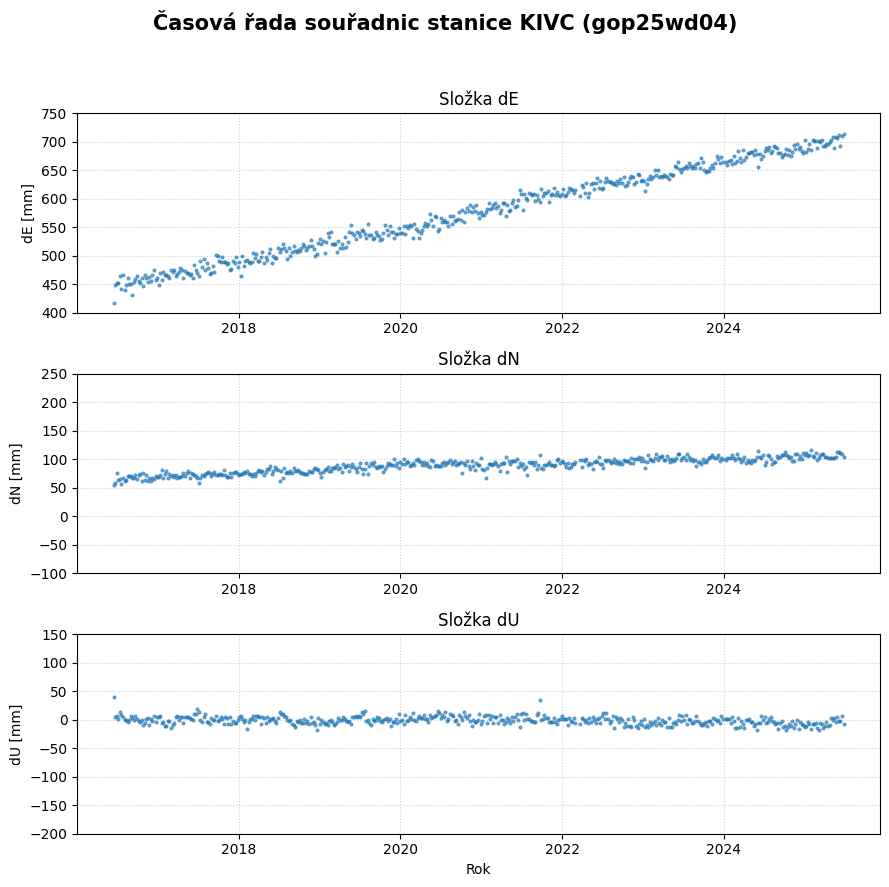

Saved PDF → ..\..\LaTeX\images\results\stations\kivc


In [7]:
# --- Plot: station coordinate time series ---

components = components  # e.g., ["dE", "dN", "dU"]

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

# Ensure axes is always iterable
if len(components) == 1:
    axes = [axes]

x_vals = df_all["year"].values  # decimal year as x-axis

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_vals = df_all[comp].values  # component values in mm

    # Plot raw observations
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        label=f"{comp} data"
    )

    # Subplot styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

# X label only on the bottom subplot
axes[-1].set_xlabel("Rok")

# Main figure title
fig.suptitle(f"Časová řada souřadnic stanice {STATION.upper()} ({SOLUTION})", fontsize=15, fontweight="bold")

# Apply consistent Y-axis scaling across subplots
tick_step, common_window = uniform_y_scale_policy(
    axes=axes,
    df=df_all,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

# Adjust layout to avoid overlap with suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
image_file_name = f"{IMAGE_NAME}_raw_data"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")

plt.show()

print(f"Saved PDF → {IMAGES_DIR}")

### Výběr časového okna

Načteme stejný soubor znovu s omezením na zvolený interval.
Parametry `start` a `end` jsou předány přímo do `load_station_dataframe`,
která interně provede filtraci a vrátí jen epochy v zadaném rozmezí.

In [8]:
# --- window (None = open interval; accepts 'YYYY-MM-DD') ---
START = "2015-01-01"
END   = "2025-12-31"

df_filt = load_station_dataframe(STCD_PATH, start=START, end=END, fill_gaps=True)

print(
    f"Window rows: {len(df_filt)} | range: "
    f"{df_filt['Date'].min()} -> {df_filt['Date'].max()}"
)
df_filt

Window rows: 472 | range: 2016-06-15 12:00:00 -> 2025-06-25 12:00:00


,MJD,Date,year,dE,dN,dU,sE,sN,sU
0,57554.5,2016-06-15 12:00:00,2016.454918,416.9,55.6,40.5,8.8,6.1,6.5
1,57561.5,2016-06-22 12:00:00,2016.474044,448.4,58.1,4.8,5.3,3.6,3.8
2,57568.5,2016-06-29 12:00:00,2016.493169,452.6,75.7,5.9,5.1,3.3,3.5
3,57575.5,2016-07-06 12:00:00,2016.512295,453.1,64.3,1.5,5.1,3.4,3.6
4,57582.5,2016-07-13 12:00:00,2016.531421,464.4,65.7,13.1,4.9,3.4,3.6
...,...,...,...,...,...,...,...,...,...
467,60823.5,2025-05-28 12:00:00,2025.404110,706.0,112.8,5.2,4.0,2.9,3.0
468,60830.5,2025-06-04 12:00:00,2025.423288,711.6,113.2,-1.6,4.3,3.0,3.2
469,60837.5,2025-06-11 12:00:00,2025.442466,692.3,110.7,-1.4,4.5,3.1,3.2
470,60844.5,2025-06-18 12:00:00,2025.461644,710.3,110.1,6.7,4.2,2.9,3.1


### Plot selected subset
plots all data vs. the selected window,

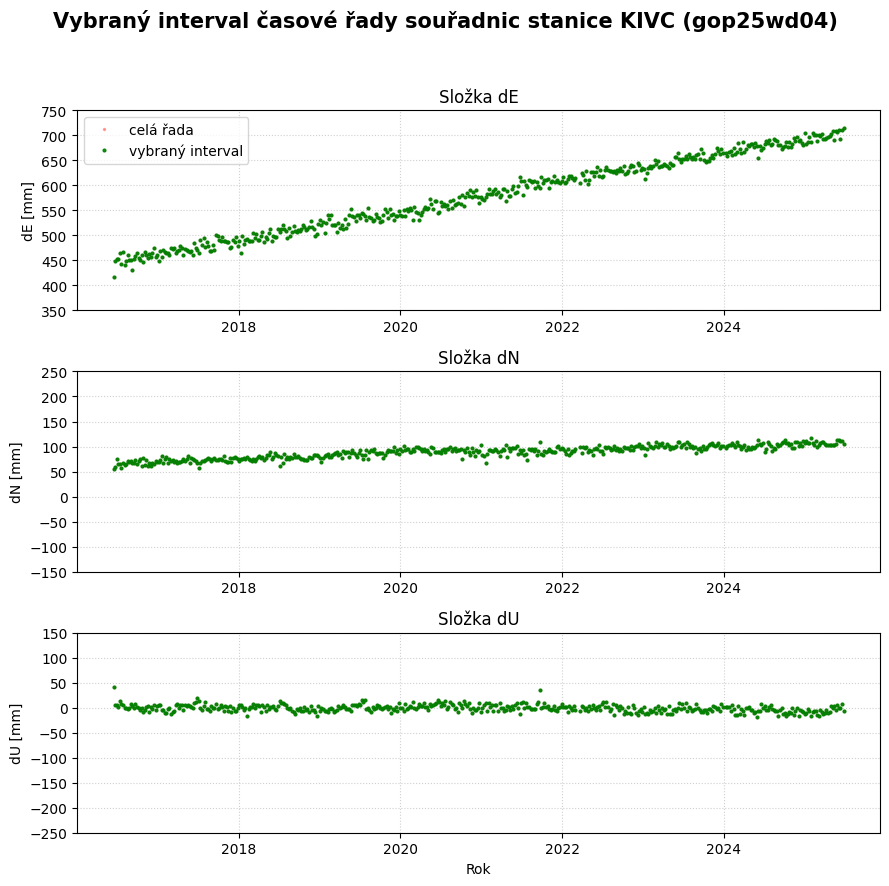

Saved PDF → ..\..\LaTeX\images\results\stations\kivc


In [9]:
# --- Plot: station coordinate time series with selected window ---

components = components  # e.g., ["dE", "dN", "dU"]

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

# Ensure axes is always iterable
if len(components) == 1:
    axes = [axes]

x_all = df_all["year"].values
x_win = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_all = pd.to_numeric(df_all[comp], errors="coerce").to_numpy()
    y_win = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    # Plot all observations as background
    ax.plot(
        x_all, y_all,
        ".",
        ms=3,
        alpha=0.30,
        color="red",
        label="celá řada"
    )

    # Plot selected window as highlighted observations
    ax.plot(
        x_win, y_win,
        ".",
        ms=4,
        alpha=0.90,
        color="green",
        label="vybraný interval"
    )

    # Subplot styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

# X label only on the bottom subplot
axes[-1].set_xlabel("Rok")

# Main figure title
fig.suptitle(
    f"Vybraný interval časové řady souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

# Add one shared legend
axes[0].legend()

# Apply consistent Y-axis scaling across subplots
tick_step, common_window = uniform_y_scale_policy(
    axes=axes,
    df=df_all,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="loose",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

# Adjust layout to avoid overlap with suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
image_file_name = f"{IMAGE_NAME}_cut"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")

plt.show()

print(f"Saved PDF → {IMAGES_DIR}")

In [10]:
# --- Export selected window before detrending ---

# Keep the same working dataframe that later trend blocks use

# Build output path
RAW_WINDOW_CSV = EXPORT_DIR / f"{IMAGE_NAME}_selected_data.csv"

# Export non-detrended selected window
df_filt.to_csv(RAW_WINDOW_CSV, index=False, float_format="%.6f")

print(f"Saved raw window CSV -> {RAW_WINDOW_CSV.resolve()}")
print(f"Rows: {len(df_filt)}")
display(df_filt.head())

Saved raw window CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_selected_data.csv
Rows: 472


,MJD,Date,year,dE,dN,dU,sE,sN,sU
0,57554.5,2016-06-15 12:00:00,2016.454918,416.9,55.6,40.5,8.8,6.1,6.5
1,57561.5,2016-06-22 12:00:00,2016.474044,448.4,58.1,4.8,5.3,3.6,3.8
2,57568.5,2016-06-29 12:00:00,2016.493169,452.6,75.7,5.9,5.1,3.3,3.5
3,57575.5,2016-07-06 12:00:00,2016.512295,453.1,64.3,1.5,5.1,3.4,3.6
4,57582.5,2016-07-13 12:00:00,2016.531421,464.4,65.7,13.1,4.9,3.4,3.6


## Shared Trend Helpers

In [11]:
# --- Shared settings and helpers for trend analysis ---

WEIGHTED = True

sigma_map = {
    "dE": "sE",
    "dN": "sN",
    "dU": "sU",
}

TREND_EXPORTS = {
    "weighted_1seg": {
        "label": "Weighted 1-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_1seg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_1seg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_1seg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_1seg.tex",
    },
    "weighted_2seg": {
        "label": "Weighted 2-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_2seg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_2seg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_2seg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_2seg.tex",
    },
    "weighted_multiseg": {
        "label": "Weighted multi-segment linear trend",
        "csv": EXPORT_DIR / f"{IMAGE_NAME}_detr_weighted_multiseg.csv",
        "fit_plot": IMAGES_DIR / f"{IMAGE_NAME}_trend_weighted_multiseg.pdf",
        "residual_plot": IMAGES_DIR / f"{IMAGE_NAME}_residuals_weighted_multiseg.pdf",
        "tex": EXPORT_DIR / f"{IMAGE_NAME}_trend_table_weighted_multiseg.tex",
    },
}


def component_sigma(comp):
    if not WEIGHTED:
        return None

    return pd.to_numeric(
        df_filt[sigma_map[comp]],
        errors="coerce"
    ).to_numpy()


def trend_summary_rows(results, variant):
    rows = []

    for comp in components:
        trend = results.get(comp)

        if trend is None:
            rows.append({
                "variant": variant,
                "axis": comp,
                "n_segments": 0,
                "breakpoints": "",
                "slopes": "",
                "intercepts": "",
                "r2": np.nan,
                "rss": np.nan,
                "wrss": np.nan,
                "bic": np.inf,
                "weighted": WEIGHTED,
                "bic_metric": "wrss" if WEIGHTED else "rss",
            })
            continue

        rows.append({
            "variant": variant,
            "axis": comp,
            "n_segments": trend.n_segments,
            "breakpoints": ", ".join(f"{bp:.3f}" for bp in trend.breakpoints),
            "slopes": ", ".join(f"{seg.slope:.3f}" for seg in trend.segments),
            "intercepts": ", ".join(f"{seg.intercept:.3f}" for seg in trend.segments),
            "r2": trend.r2,
            "rss": trend.rss,
            "wrss": trend.wrss,
            "bic": trend.bic,
            "weighted": trend.weighted,
            "bic_metric": trend.bic_metric,
        })

    return rows


def build_detrended_dataframe(results):
    out = df_filt.copy()

    for comp in components:
        trend = results.get(comp)

        if trend is None:
            out[f"fit_{comp}"] = np.nan
            out[f"res_{comp}"] = np.nan
            out[f"seg_{comp}"] = -1
            continue

        trend_df = trend.to_dataframe()

        out[f"fit_{comp}"] = trend_df["fitted"].to_numpy()
        out[f"res_{comp}"] = trend_df["residual"].to_numpy()
        out[f"seg_{comp}"] = trend_df["segment_id"].to_numpy()

    return out

## Weighted 1-Segment Trend

This block fits the weighted one-segment trend and exports its raw PDF, fitted-trend PDF, detrended CSV, residual PDF, and LaTeX table.

In [12]:
# --- Weighted 1-segment linear trend ---

VARIANT = "weighted_1seg"
CONFIG = TREND_EXPORTS[VARIANT]

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend1_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend1_results[comp] = fit_linear_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),  # weighted fit
            bic_metric="auto",
        )
    except ValueError:
        trend1_results[comp] = None

rows = []

for comp in components:
    trend = trend1_results.get(comp)

    if trend is None:
        rows.append({
            "axis": comp,
            "slope": np.nan,
            "intercept": np.nan,
            "r2": np.nan,
            "rss": np.nan,
            "wrss": np.nan,
            "bic": np.inf,
            "weighted": True,
        })
        continue

    rows.append({
        "axis": comp,
        "slope": trend.slope,
        "intercept": trend.intercept,
        "r2": trend.r2,
        "rss": trend.rss,
        "wrss": trend.wrss,
        "bic": trend.bic,
        "weighted": trend.weighted,
    })

trend1_df = pd.DataFrame(rows).set_index("axis", drop=False)

display(trend1_df[["slope", "intercept", "r2", "rss", "wrss", "bic", "weighted"]].round(3))

,slope,intercept,r2,rss,wrss,bic,weighted
axis,,,,,,,
dE,29.073,-58178.056,0.988,33465.073,1453.940,542.942,True
dN,4.243,-8485.770,0.791,15651.250,1470.018,548.099,True
dU,-0.725,1463.520,0.088,21371.575,1684.916,612.090,True


In [13]:
# --- Weighted 1-segment LaTeX table ---

latex_1seg = trend1_df[
    ["axis", "slope", "intercept", "r2", "wrss", "bic", "weighted"]
].round(3).to_latex(
    index=False,
    caption="Vážený lineární trend bez zlomů",
    label=f"tab:{IMAGE_NAME}_weighted_1seg",
    escape=False,
)

CONFIG["tex"].write_text(latex_1seg, encoding="utf-8")

print(latex_1seg)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený lineární trend bez zlomů}
\label{tab:gop25wd04_stcd_kivc_weighted_1seg}
\begin{tabular}{lrrrrrr}
\toprule
axis & slope & intercept & r2 & wrss & bic & weighted \\
\midrule
dE & 29.073000 & -58178.056000 & 0.988000 & 1453.940000 & 542.942000 & True \\
dN & 4.243000 & -8485.770000 & 0.791000 & 1470.018000 & 548.099000 & True \\
dU & -0.725000 & 1463.520000 & 0.088000 & 1684.916000 & 612.090000 & True \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_trend_table_weighted_1seg.tex


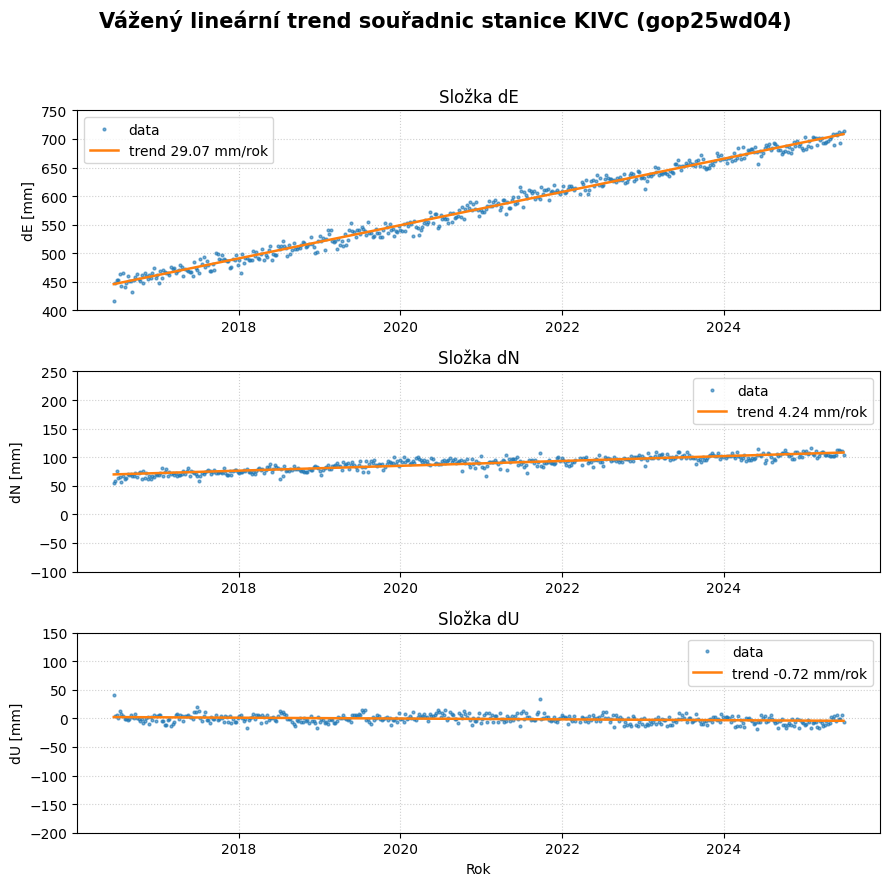

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_trend_weighted_1seg.pdf


In [14]:
# --- Plot: weighted 1-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    # Data
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="data"
    )

    # Trend
    trend = trend1_results.get(comp)

    if trend is not None:
        x_fit = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 200)
        y_fit = trend.intercept + trend.slope * x_fit

        ax.plot(
            x_fit, y_fit,
            "-",
            lw=1.8,
            color="tab:orange",   # 🔥 matplotlib default orange
            label=f"trend {trend.slope:.2f} mm/rok"
        )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 🔥 legenda pro každý subplot
    ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený lineární trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [15]:
# Weighted 1-segment detrending and CSV export
df_detr_1seg = build_detrended_dataframe(trend1_results)
df_detr_1seg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")
print("Saved CSV ->", CONFIG["csv"].resolve())
display(df_detr_1seg[["year"] + [f"res_{c}" for c in components]].head())

Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_detr_weighted_1seg.csv


,year,res_dE,res_dN,res_dU
0,2016.454918,-29.128517,-14.361887,38.189182
1,2016.474044,1.815445,-11.943036,2.503041
2,2016.493169,5.459407,5.575814,3.616900
3,2016.512295,5.403369,-5.905335,-0.769240
4,2016.531421,16.147331,-4.586485,10.844619


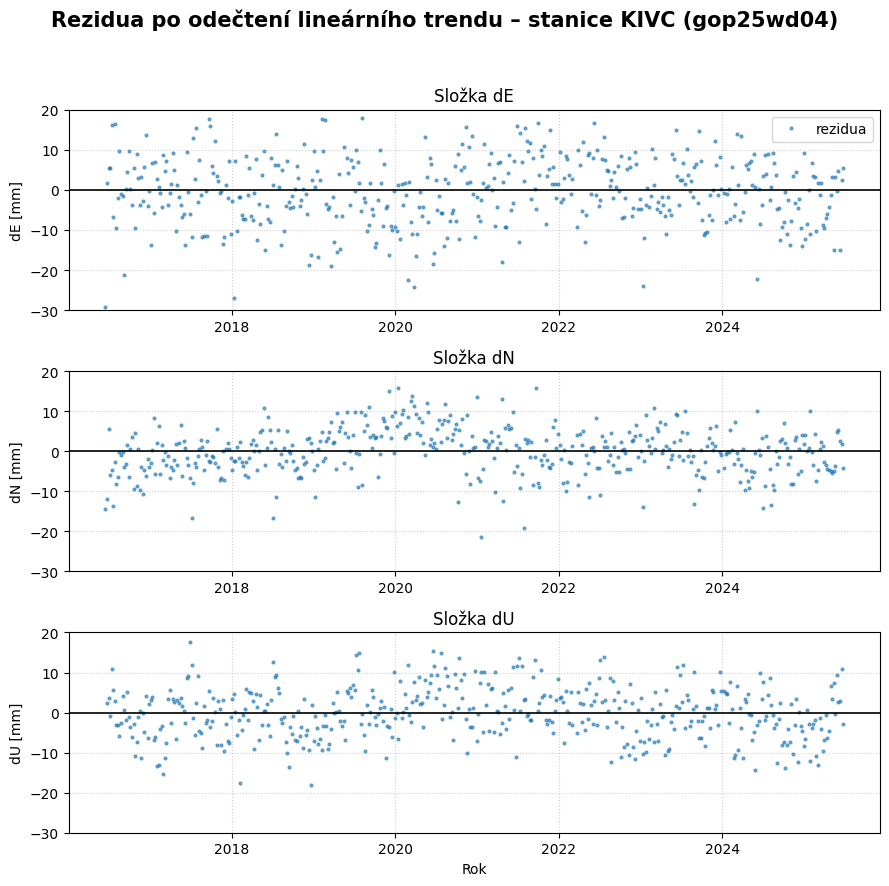

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_residuals_weighted_1seg.pdf


In [16]:
# --- Plot: residuals (weighted 1-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_1seg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_1seg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None  # legend only once
    )

    # Zero reference line
    ax.axhline(
        0,
        color="black",
        lw=1.2,
        linestyle="-"
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Legend only on first subplot
    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení lineárního trendu – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_1seg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())

## Weighted 2-Segment Trend

This block fits the weighted two-segment trend and exports its raw PDF, fitted-trend PDF, detrended CSV, residual PDF, and LaTeX table.

In [17]:
# --- Weighted 2-segment linear trend ---

VARIANT = "weighted_2seg"
CONFIG = TREND_EXPORTS[VARIANT]

MIN_POINTS_2SEG = 8

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend2_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend2_results[comp] = fit_piecewise_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),
            max_segments=2,
            force_max_segments=True,
            min_points=MIN_POINTS_2SEG,
            min_years=0.0,
            bic_metric="auto",
        )
    except ValueError:
        trend2_results[comp] = None

trend2_df = pd.DataFrame(
    trend_summary_rows(trend2_results, VARIANT)
).set_index("axis", drop=False)

# Compute jump at the breakpoint:
# jump = value after breakpoint - value before breakpoint
for comp in components:
    trend = trend2_results.get(comp)

    if trend is None or len(trend.breakpoints) != 1 or len(trend.segments) != 2:
        trend2_df.loc[comp, "jump"] = np.nan
        continue

    bp = trend.breakpoints[0]

    left_segment = trend.segments[0]
    right_segment = trend.segments[1]

    y_before = left_segment.intercept + left_segment.slope * bp
    y_after = right_segment.intercept + right_segment.slope * bp

    trend2_df.loc[comp, "jump"] = y_after - y_before

display(
    trend2_df[
        [
            "n_segments",
            "breakpoints",
            "slopes",
            "jump",
            "r2",
            "wrss",
            "bic",
            "weighted",
        ]
    ].round(3)
)

,n_segments,breakpoints,slopes,jump,r2,wrss,bic,weighted
axis,,,,,,,,
dE,2,2020.786,"27.796, 27.359",9.125,0.989,1342.056,523.839,True
dN,2,2020.747,"6.952, 3.999",-6.560,0.828,1215.255,477.291,True
dU,2,2019.388,"-1.782, -1.725",7.062,0.166,1536.114,587.178,True


In [18]:
# --- Weighted 2-segment LaTeX table (full version, cleaned) ---

latex_2seg = trend2_df[
    ["axis", "n_segments", "breakpoints", "slopes", "jump", "r2", "wrss", "bic"]
].copy()

# Rename columns (Czech, readable)
latex_2seg = latex_2seg.rename(columns={
    "axis": "Složka",
    "n_segments": "Segmenty",
    "breakpoints": "Zlom [rok]",
    "slopes": "Směrnice [mm/rok]",
    "jump": "Skok [mm]",
    "r2": "$R^2$",
    "wrss": "WRSS [-]",
    "bic": "BIC [-]",
})

# Round only numeric columns
for col in ["Skok [mm]", "$R^2$", "WRSS [-]", "BIC [-]"]:
    latex_2seg[col] = pd.to_numeric(latex_2seg[col], errors="coerce").round(3)

# Export
latex_str = latex_2seg.to_latex(
    index=False,
    caption=(
        f"Vážený dvousegmentový lineární trend souřadnic "
        f"stanice {STATION.upper()} (řešení {SOLUTION})"
    ),
    label=f"tab:{IMAGE_NAME}_weighted_2seg",
    escape=False,
)

CONFIG["tex"].write_text(latex_str, encoding="utf-8")

print(latex_str)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený dvousegmentový lineární trend souřadnic stanice KIVC (řešení gop25wd04)}
\label{tab:gop25wd04_stcd_kivc_weighted_2seg}
\begin{tabular}{lrllrrrr}
\toprule
Složka & Segmenty & Zlom [rok] & Směrnice [mm/rok] & Skok [mm] & $R^2$ & WRSS [-] & BIC [-] \\
\midrule
dE & 2 & 2020.786 & 27.796, 27.359 & 9.125000 & 0.989000 & 1342.056000 & 523.839000 \\
dN & 2 & 2020.747 & 6.952, 3.999 & -6.560000 & 0.828000 & 1215.255000 & 477.291000 \\
dU & 2 & 2019.388 & -1.782, -1.725 & 7.062000 & 0.166000 & 1536.114000 & 587.178000 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_trend_table_weighted_2seg.tex


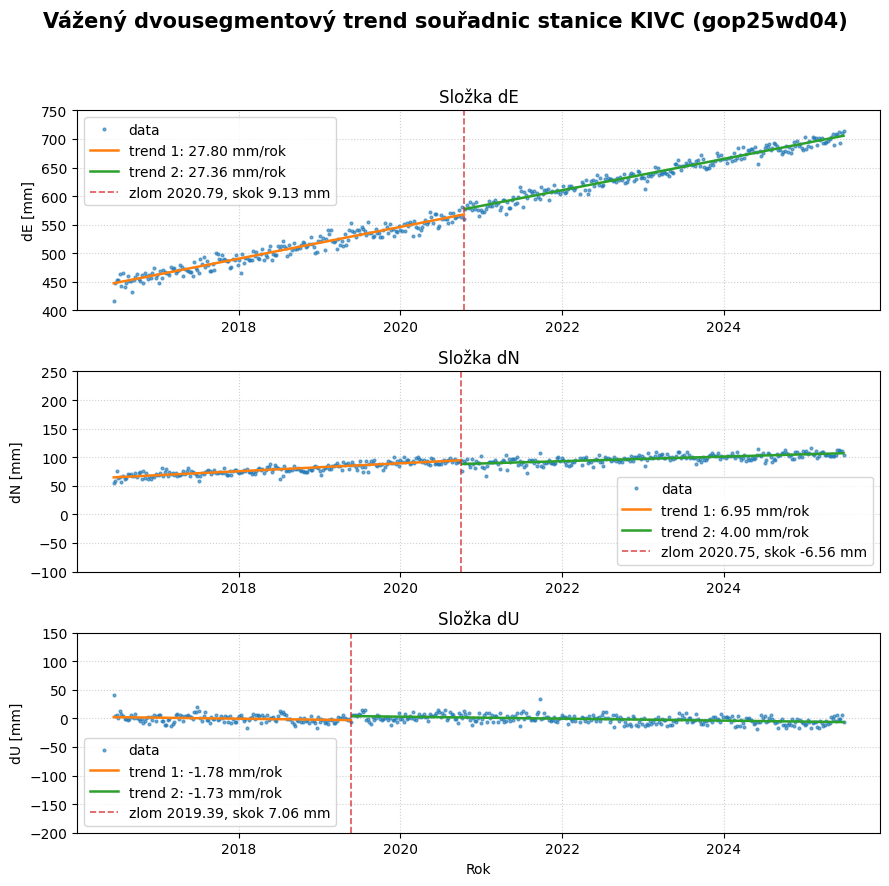

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_trend_weighted_2seg.pdf


In [19]:
# --- Plot: weighted 2-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

trend_colors = ["tab:orange", "tab:green", "tab:purple", "tab:brown"]

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="data"
    )

    trend = trend2_results.get(comp)

    if trend is not None:
        for i, seg in enumerate(trend.segments):
            x_fit = np.linspace(seg.x_min, seg.x_max, 200)
            y_fit = seg.intercept + seg.slope * x_fit

            ax.plot(
                x_fit, y_fit,
                "-",
                lw=1.8,
                color=trend_colors[i % len(trend_colors)],
                label=f"trend {i+1}: {seg.slope:.2f} mm/rok"
            )

        for bp in trend.breakpoints:
            jump = trend2_df.loc[comp, "jump"]

            ax.axvline(
                bp,
                linestyle="--",
                linewidth=1.2,
                color="tab:red",
                alpha=0.8,
                label=f"zlom {bp:.2f}, skok {jump:.2f} mm"
            )

    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený dvousegmentový trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [20]:
# Weighted 2-segment detrending and CSV export
df_detr_2seg = build_detrended_dataframe(trend2_results)
df_detr_2seg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")
print("Saved CSV ->", CONFIG["csv"].resolve())
display(df_detr_2seg[["year"] + [f"res_{c}" for c in components]].head())


Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_detr_weighted_2seg.csv


,year,res_dE,res_dN,res_dU
0,2016.454918,-30.646371,-9.216139,38.293858
1,2016.474044,0.322018,-6.849094,2.627949
2,2016.493169,3.990406,10.617951,3.762040
3,2016.512295,3.958795,-0.915004,-0.603869
4,2016.531421,14.727183,0.352041,11.030221


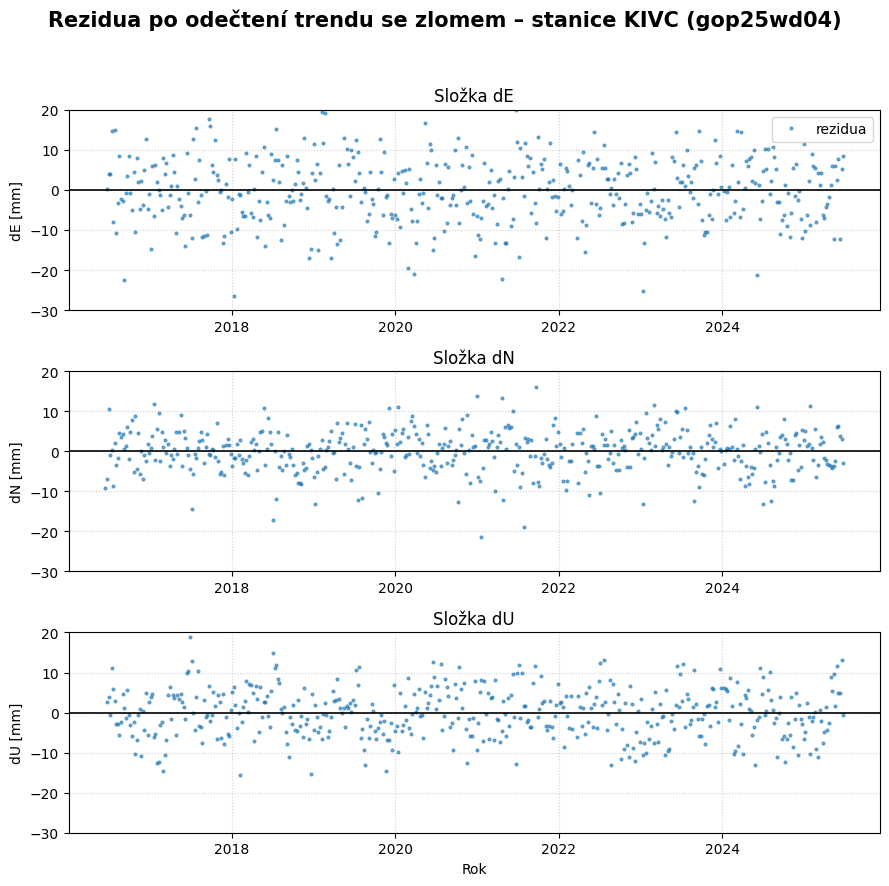

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_residuals_weighted_2seg.pdf


In [21]:
# --- Plot: residuals (weighted 2-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_2seg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_2seg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1.2
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení trendu se zlomem – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_2seg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())

## Weighted Multi-Segment Trend

This block follows the multi-segment workflow from `Trend_detection.ipynb`, but delegates fitting to `fit_piecewise_trend(...)` from the station trend module and exports raw, fitted, and detrended PDF outputs.

In [22]:
# --- Weighted multi-segment linear trend ---

VARIANT = "weighted_multiseg"
CONFIG = TREND_EXPORTS[VARIANT]

MIN_POINTS_MULTI = 10
MIN_YEARS_MULTI = 1.0
MAX_SEGMENTS_MULTI = 8

x_all = pd.to_numeric(df_filt["year"], errors="coerce").to_numpy()

trend_multi_results = {}

for comp in components:
    y_all = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    try:
        trend_multi_results[comp] = fit_piecewise_trend(
            x_all,
            y_all,
            sigma=component_sigma(comp),
            max_segments=MAX_SEGMENTS_MULTI,
            force_max_segments=False,
            min_points=MIN_POINTS_MULTI,
            min_years=MIN_YEARS_MULTI,
            bic_metric="auto",
        )
    except ValueError:
        trend_multi_results[comp] = None

trend_multi_df = pd.DataFrame(
    trend_summary_rows(trend_multi_results, VARIANT)
).set_index("axis", drop=False)

# Compute jumps at all breakpoints:
# jump = value after breakpoint - value before breakpoint
for comp in components:
    trend = trend_multi_results.get(comp)

    if trend is None or len(trend.breakpoints) == 0:
        trend_multi_df.loc[comp, "jumps"] = ""
        continue

    jumps = []

    for i, bp in enumerate(trend.breakpoints):
        left_segment = trend.segments[i]
        right_segment = trend.segments[i + 1]

        y_before = left_segment.intercept + left_segment.slope * bp
        y_after = right_segment.intercept + right_segment.slope * bp

        jumps.append(y_after - y_before)

    trend_multi_df.loc[comp, "jumps"] = ", ".join(f"{j:.3f}" for j in jumps)

display(
    trend_multi_df[
        [
            "n_segments",
            "breakpoints",
            "slopes",
            "jumps",
            "r2",
            "wrss",
            "bic",
            "weighted",
        ]
    ].round(3)
)

,n_segments,breakpoints,slopes,jumps,r2,wrss,bic,weighted
axis,,,,,,,,
dE,2,2020.786,"27.796, 27.359",9.125,0.989,1342.056,523.839,True
dN,2,2020.747,"6.952, 3.999",-6.560,0.828,1215.255,477.291,True
dU,2,2019.388,"-1.782, -1.725",7.062,0.166,1536.114,587.178,True


In [23]:
# --- Weighted multi-segment LaTeX table (clean version) ---

latex_multiseg = trend_multi_df[
    ["axis", "n_segments", "breakpoints", "slopes", "jumps", "r2", "wrss", "bic"]
].copy()

latex_multiseg = latex_multiseg.rename(columns={
    "axis": "Složka",
    "n_segments": "Segmenty",
    "breakpoints": "Zlomy [rok]",
    "slopes": "Směrnice [mm/rok]",
    "jumps": "Skoky [mm]",
    "r2": "$R^2$",
    "wrss": "WRSS [-]",
    "bic": "BIC [-]",
})

# round numeric columns only
for col in ["$R^2$", "WRSS [-]", "BIC [-]"]:
    latex_multiseg[col] = pd.to_numeric(latex_multiseg[col], errors="coerce").round(3)

latex_str = latex_multiseg.to_latex(
    index=False,
    caption=(
        f"Vážený vícesegmentový lineární trend souřadnic "
        f"stanice {STATION.upper()} (řešení {SOLUTION})"
    ),
    label=f"tab:{IMAGE_NAME}_weighted_multiseg",
    escape=False,
)

CONFIG["tex"].write_text(latex_str, encoding="utf-8")

print(latex_str)
print("Saved TeX ->", CONFIG["tex"].resolve())

\begin{table}
\caption{Vážený vícesegmentový lineární trend souřadnic stanice KIVC (řešení gop25wd04)}
\label{tab:gop25wd04_stcd_kivc_weighted_multiseg}
\begin{tabular}{lrlllrrr}
\toprule
Složka & Segmenty & Zlomy [rok] & Směrnice [mm/rok] & Skoky [mm] & $R^2$ & WRSS [-] & BIC [-] \\
\midrule
dE & 2 & 2020.786 & 27.796, 27.359 & 9.125 & 0.989000 & 1342.056000 & 523.839000 \\
dN & 2 & 2020.747 & 6.952, 3.999 & -6.560 & 0.828000 & 1215.255000 & 477.291000 \\
dU & 2 & 2019.388 & -1.782, -1.725 & 7.062 & 0.166000 & 1536.114000 & 587.178000 \\
\bottomrule
\end{tabular}
\end{table}

Saved TeX -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_trend_table_weighted_multiseg.tex


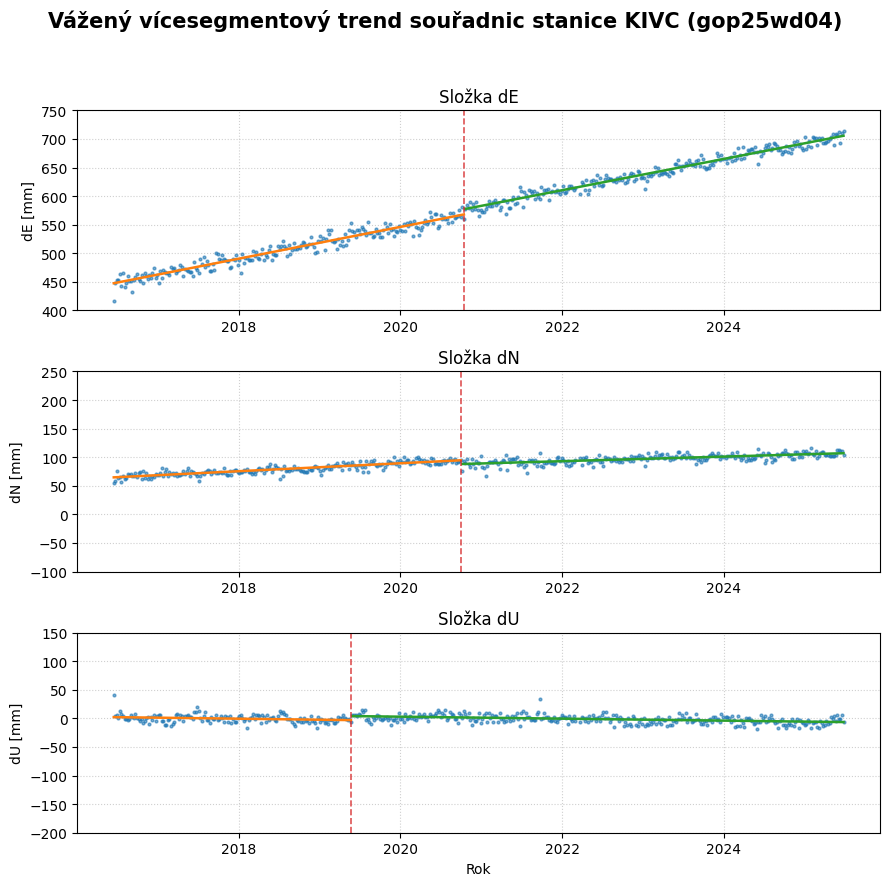

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_trend_weighted_multiseg.pdf


In [24]:
# --- Plot: weighted multi-segment linear trend ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_filt["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

trend_colors = ["tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

for ax, comp in zip(axes, components):
    y_vals = pd.to_numeric(df_filt[comp], errors="coerce").to_numpy()

    # Data
    ax.plot(
        x_vals, y_vals,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue"
    )

    # Multi-segment trend
    trend = trend_multi_results.get(comp)

    if trend is not None:
        for i, seg in enumerate(trend.segments):
            x_fit = np.linspace(seg.x_min, seg.x_max, 200)
            y_fit = seg.intercept + seg.slope * x_fit

            ax.plot(
                x_fit, y_fit,
                "-",
                lw=1.8,
                color=trend_colors[i % len(trend_colors)]
            )

        for bp in trend.breakpoints:
            ax.axvline(
                bp,
                linestyle="--",
                linewidth=1.2,
                color="tab:red",
                alpha=0.8
            )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Vážený vícesegmentový trend souřadnic stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_filt,
    components=components,
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["fit_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["fit_plot"].resolve())

In [25]:
# Weighted multi-segment detrending and CSV export
df_detr_multiseg = build_detrended_dataframe(trend_multi_results)

df_detr_multiseg.to_csv(CONFIG["csv"], index=False, float_format="%.6f")

print("Saved CSV ->", CONFIG["csv"].resolve())

display(
    df_detr_multiseg[
        ["year"] + [f"res_{c}" for c in components]
    ].head()
)

Saved CSV -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\kivc\gop25wd04_stcd_kivc_detr_weighted_multiseg.csv


,year,res_dE,res_dN,res_dU
0,2016.454918,-30.646371,-9.216139,38.293858
1,2016.474044,0.322018,-6.849094,2.627949
2,2016.493169,3.990406,10.617951,3.762040
3,2016.512295,3.958795,-0.915004,-0.603869
4,2016.531421,14.727183,0.352041,11.030221


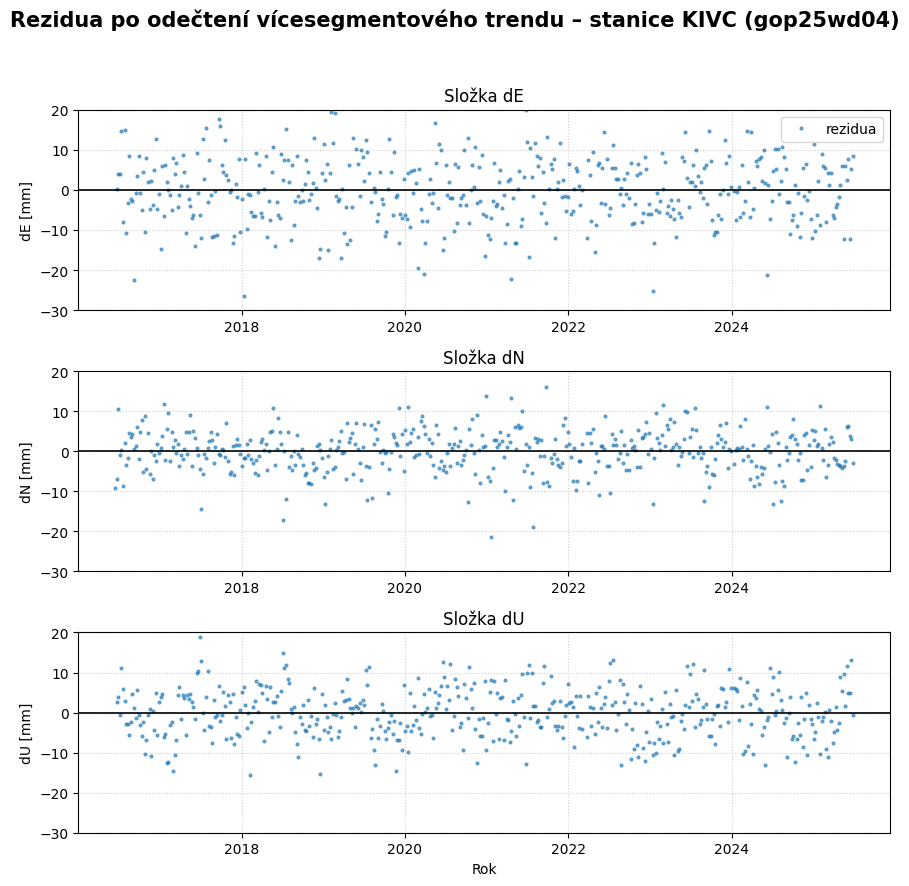

Saved PDF -> C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\stations\kivc\gop25wd04_stcd_kivc_residuals_weighted_multiseg.pdf


In [26]:
# --- Plot: residuals (weighted multi-segment) ---

components = components

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=True, sharey=False)

if len(components) == 1:
    axes = [axes]

x_vals = df_detr_multiseg["year"].values

component_titles = {
    "dE": "Složka dE",
    "dN": "Složka dN",
    "dU": "Složka dU",
}

for i, (ax, comp) in enumerate(zip(axes, components)):
    y_res = pd.to_numeric(df_detr_multiseg[f"res_{comp}"], errors="coerce").to_numpy()

    # Residuals
    ax.plot(
        x_vals, y_res,
        ".",
        ms=4,
        alpha=0.6,
        color="tab:blue",
        label="rezidua" if i == 0 else None
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1.2
    )

    # Styling
    ax.set_title(component_titles.get(comp, comp), fontweight="normal")
    ax.set_ylabel(f"{comp} [mm]")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, linestyle=":", alpha=0.6)

    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Rok")

fig.suptitle(
    f"Rezidua po odečtení vícesegmentového trendu – stanice {STATION.upper()} ({SOLUTION})",
    fontsize=15,
    fontweight="bold"
)

uniform_y_scale_policy(
    axes=axes,
    df=df_detr_multiseg,
    components=[f"res_{c}" for c in components],
    tick_step=None,
    target_ticks=6,
    tightness="tight",
    min_ticks=3,
    robust=True,
    q_low=1.0,
    q_high=99.0
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(CONFIG["residual_plot"], bbox_inches="tight")

plt.show()

print("Saved PDF ->", CONFIG["residual_plot"].resolve())